In [3]:
from ultralytics import YOLO

In [4]:
model = YOLO("/Users/guestuser/Documents/Projects/what-do-i-wear-today/models/weights.pt")


image 1/1 /Users/guestuser/Documents/Projects/what-do-i-wear-today/experiments/test-images/test_3.png: 640x480 1 short sleeve top, 2 trouserss, 211.6ms
Speed: 4.0ms preprocess, 211.6ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 480)


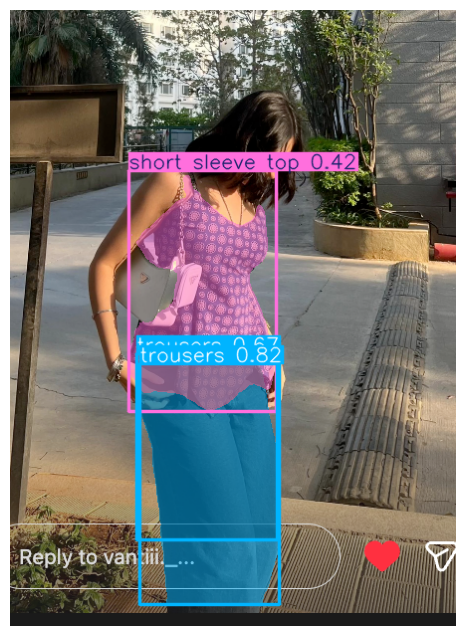

In [15]:
import matplotlib.pyplot as plt

image_path="/Users/guestuser/Documents/Projects/what-do-i-wear-today/experiments/test-images/test_3.png"

# Run inference
results = model(image_path)
result = results[0]

# Render predictions and convert BGR to RGB for matplotlib
annotated_image = result.plot(masks=True, boxes=True, labels=True)
annotated_image = annotated_image[..., ::-1]

# Display the annotated image
plt.figure(figsize=(10, 8))
plt.imshow(annotated_image)
plt.axis("off")
plt.show()

In [16]:
# Export the loaded YOLO model to ONNX format
onnx_path = model.export(
    format="onnx",
    simplify=True
)

print(f"ONNX model exported to: {onnx_path}")

Ultralytics 8.4.174 🚀 Python-3.9.6 torch-2.8.0 CPU (Apple A18 Pro)
YOLO26s-seg summary (fused): 136 layers, 10,370,371 parameters, 0 gradients, 34.3 GFLOPs

PyTorch: starting from '/Users/guestuser/Documents/Projects/what-do-i-wear-today/models/weights.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) ((1, 49, 8400), (1, 32, 160, 160)) (22.3 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
You should consider upgrading via the '/Users/guestuser/Documents/Projects/what-do-i-wear-today/.venv/bin/python -m pip install --upgrade pip' command.

requirements: AutoUpdate success ✅ 20.4s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.19.1 opset 18...
ONNX: slimming with onnxslim 0.1.97...
ONNX: export success ✅ 23.2s, saved as '/Users/guestuser/Documents/Projects/what-do-i-wear-today/models/weights.onnx' (39.9 MB)

Expor

Extract segmented areas.

In [19]:
import numpy as np
import cv2

In [18]:
results = model(image_path)


image 1/1 /Users/guestuser/Documents/Projects/what-do-i-wear-today/experiments/test-images/test_3.png: 640x480 1 short sleeve top, 2 trouserss, 291.3ms
Speed: 31.5ms preprocess, 291.3ms inference, 23.6ms postprocess per image at shape (1, 3, 640, 480)


In [28]:
orig_img = cv2.imread(image_path)

In [30]:
import os

In [33]:
def crop(result, output_dir="runs/segment/cropped"):
    if result.masks is None:
        return []

    image = result.orig_img
    height, width = image.shape[:2]
    masks = result.masks.data.cpu().numpy()
    boxes = result.boxes.xyxy.cpu().numpy()

    os.makedirs(output_dir, exist_ok=True)
    saved_paths = []

    for j, mask in enumerate(masks):
        mask_resized = cv2.resize(
            mask,
            (width, height),
            interpolation=cv2.INTER_NEAREST,
        )
        alpha = (mask_resized > 0.5).astype(np.uint8) * 255

        b, g, r = cv2.split(image)
        transparent_image = cv2.merge([b, g, r, alpha])

        x1, y1, x2, y2 = map(int, boxes[j])
        x1, x2 = max(0, x1), min(width, x2)
        y1, y2 = max(0, y1), min(height, y2)

        cropped = transparent_image[y1:y2, x1:x2]
        output_path = os.path.join(
            output_dir,
            f"segmented_object_{j}_transparent.png",
        )

        cv2.imwrite(output_path, cropped)
        saved_paths.append(output_path)

    return saved_paths

In [34]:
crop(result)

['runs/segment/cropped/segmented_object_0_transparent.png',
 'runs/segment/cropped/segmented_object_1_transparent.png',
 'runs/segment/cropped/segmented_object_2_transparent.png']